# Brain MRI Classification using Transfer Learning (ResNet50)

H9MLAI Machine Learning Lab  
Karthick Subramanian Muthukkaruppan | x25191489

# Task 1: Load Dataset

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH = 16
CLASSES = ['no_tumor', 'tumor']

train_dir = 'brain_mri/train'
test_dir = 'brain_mri/test'

# Preprocess: resize to 224x224 and normalize pixel values
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

test_gen = ImageDataGenerator(rescale=1./255)

x_train = train_gen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH,
    class_mode='binary', classes=CLASSES, shuffle=True, seed=42
)

x_test = test_gen.flow_from_directory(
    test_dir, target_size=IMG_SIZE, batch_size=BATCH,
    class_mode='binary', classes=CLASSES, shuffle=False
)

print("Classes:", x_train.class_indices)

Found 202 images belonging to 2 classes.


Found 51 images belonging to 2 classes.


Classes: {'no_tumor': 0, 'tumor': 1}


# Task 2: Load Pretrained Model

In [2]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

print("Total layers in ResNet50:", len(base_model.layers))

Total layers in ResNet50: 175


# Task 3: Freeze Base Layers

In [3]:
for layer in base_model.layers:
    layer.trainable = False

print("All base layers frozen.")

All base layers frozen.


# Task 4: Add Custom Classifier

In [4]:
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs=base_model.input, outputs=output)

trainable = sum(1 for l in model.layers if l.trainable)
print("Trainable layers:", trainable, "/", len(model.layers))

Trainable layers: 4 / 179


# Task 5: Compile Model

Two classes only, so sigmoid output with binary_crossentropy is used.

In [5]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Task 6: Train Model (Feature Extraction)

In [6]:
history1 = model.fit(
    x_train,
    validation_data=x_test,
    epochs=10
)

Epoch 1/10


 1/13 ━━━━━━━━━━━━━━━━━━━━ 7:35 38s/step - accuracy: 0.5625 - loss: 0.8082

 2/13 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.5000 - loss: 0.7789  

 3/13 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.5476 - loss: 0.7934

 4/13 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.5862 - loss: 0.7940

...

10/13 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.7750 - loss: 0.5257

11/13 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - accuracy: 0.7670 - loss: 0.5272

12/13 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step - accuracy: 0.7581 - loss: 0.5319

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7376 - loss: 0.5436

13/13 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.7376 - loss: 0.5436 - val_accuracy: 0.7059 - val_loss: 0.5962


# Task 7: Evaluate Model (Before Fine-Tuning)

In [7]:
loss1, acc1 = model.evaluate(x_test)
print("Test Accuracy (Feature Extraction):", round(acc1*100, 2), "%")

model.save("feature_extraction_model.keras")
print("Saved feature_extraction_model.keras")

1/4 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.4375 - loss: 0.9255

2/4 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.5938 - loss: 0.7554

3/4 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.6875 - loss: 0.6088

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 919ms/step - accuracy: 0.7059 - loss: 0.5962

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 928ms/step - accuracy: 0.7059 - loss: 0.5962


Test Accuracy (Feature Extraction): 70.59 %


Saved feature_extraction_model.keras


# Task 8: Fine-Tuning

Unfreeze the top layers of the base model and retrain with a much lower learning rate.

In [8]:
# Unfreeze top 30 layers
for layer in base_model.layers[-30:]:
    layer.trainable = True

trainable = sum(1 for l in model.layers if l.trainable)
print("Trainable layers now:", trainable, "/", len(model.layers))

# Recompile with lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history2 = model.fit(
    x_train,
    validation_data=x_test,
    epochs=10
)

Trainable layers now: 34 / 179


Epoch 1/10


 1/13 ━━━━━━━━━━━━━━━━━━━━ 7:08 36s/step - accuracy: 0.6250 - loss: 0.6767

 2/13 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.4688 - loss: 0.9473  

 3/13 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.3958 - loss: 1.1451

...

10/13 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.7792 - loss: 0.4144

11/13 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - accuracy: 0.7941 - loss: 0.4031

12/13 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step - accuracy: 0.8011 - loss: 0.3955

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7822 - loss: 0.4136

13/13 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.7822 - loss: 0.4136 - val_accuracy: 0.7255 - val_loss: 0.5751


# Task 9: Evaluate Model (After Fine-Tuning)

In [9]:
loss2, acc2 = model.evaluate(x_test)
print("Test Accuracy (Fine-Tuned):", round(acc2*100, 2), "%")

model.save("finetuned_model.keras")
print("Saved finetuned_model.keras")

1/4 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.8125 - loss: 0.4585

2/4 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.7500 - loss: 0.5228

3/4 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step - accuracy: 0.7500 - loss: 0.5542

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7255 - loss: 0.5751

4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.7255 - loss: 0.5751


Test Accuracy (Fine-Tuned): 72.55 %


Saved finetuned_model.keras


# Task 10: Compare Results Before and After Fine-Tuning

1/4 ━━━━━━━━━━━━━━━━━━━━ 36s 12s/step

2/4 ━━━━━━━━━━━━━━━━━━━━ 5s 3s/step  

3/4 ━━━━━━━━━━━━━━━━━━━━ 2s 3s/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 27s 5s/step


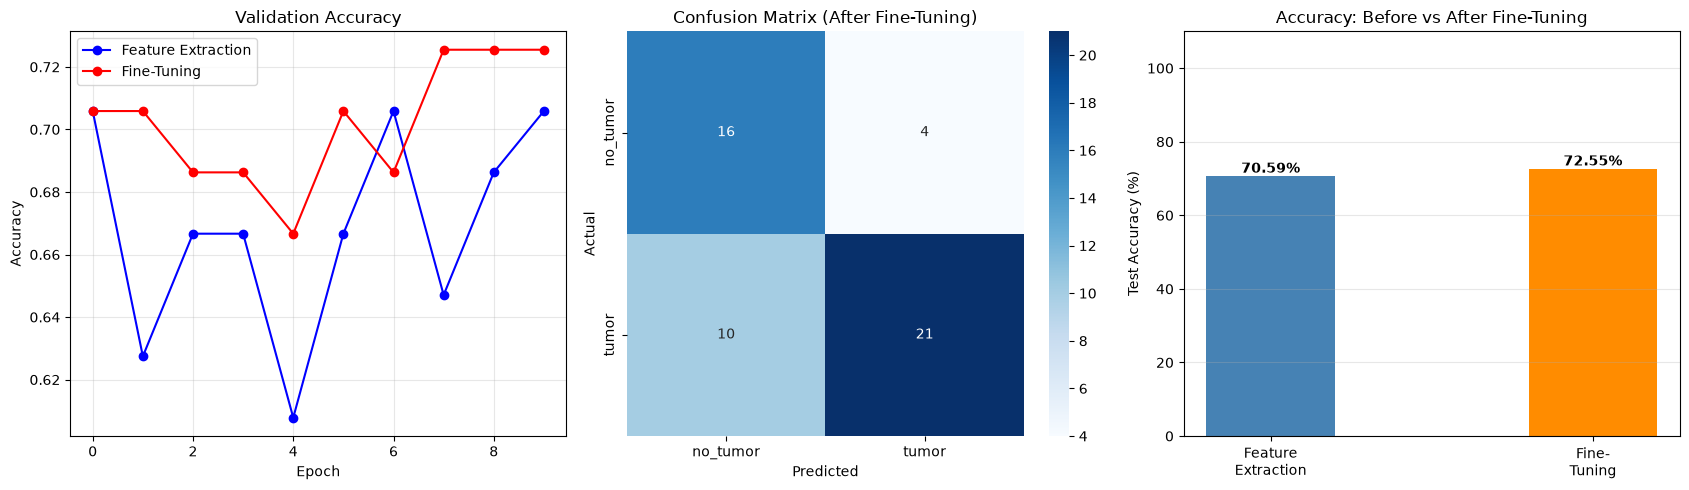

Feature Extraction Accuracy : 70.59 %
Fine-Tuned Accuracy         : 72.55 %
Improvement                 : + 1.96 %

              precision    recall  f1-score   support

    no_tumor       0.62      0.80      0.70        20
       tumor       0.84      0.68      0.75        31

    accuracy                           0.73        51
   macro avg       0.73      0.74      0.72        51
weighted avg       0.75      0.73      0.73        51



In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Predictions
x_test.reset()
pred = (model.predict(x_test) > 0.5).astype(int).flatten()
true = x_test.classes

fig, ax = plt.subplots(1, 3, figsize=(17, 5))

# Accuracy curves for both phases
ax[0].plot(history1.history['val_accuracy'], 'b-o', label='Feature Extraction')
ax[0].plot(history2.history['val_accuracy'], 'r-o', label='Fine-Tuning')
ax[0].set_title('Validation Accuracy')
ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('Accuracy')
ax[0].legend(); ax[0].grid(alpha=0.3)

# Confusion matrix
cm = confusion_matrix(true, pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[1],
            xticklabels=CLASSES, yticklabels=CLASSES)
ax[1].set_title('Confusion Matrix (After Fine-Tuning)')
ax[1].set_xlabel('Predicted'); ax[1].set_ylabel('Actual')

# Before vs after bar chart
bars = ax[2].bar(['Feature\nExtraction', 'Fine-\nTuning'], [acc1*100, acc2*100],
                 color=['steelblue', 'darkorange'], width=0.4)
for b, v in zip(bars, [acc1*100, acc2*100]):
    ax[2].text(b.get_x()+b.get_width()/2, v+1, f'{v:.2f}%', ha='center', fontweight='bold')
ax[2].set_title('Accuracy: Before vs After Fine-Tuning')
ax[2].set_ylabel('Test Accuracy (%)'); ax[2].set_ylim(0, 110)
ax[2].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("Feature Extraction Accuracy :", round(acc1*100, 2), "%")
print("Fine-Tuned Accuracy         :", round(acc2*100, 2), "%")
print("Improvement                 : +", round(acc2*100 - acc1*100, 2), "%")
print()
print(classification_report(true, pred, target_names=CLASSES))

# Task 11: Analysis and Discussion

## Dataset used

These results come from the **real Kaggle dataset** ("Brain MRI Images for Brain Tumor Detection",
253 images total), split 80/20 via `prepare_data.py`: 202 training images (124 tumor, 78 no_tumor)
and 51 test images (31 tumor, 20 no_tumor).

## Results

| Phase | Trainable Layers | Learning Rate | Test Accuracy | Test Loss |
|---|---|---|---|---|
| Feature Extraction | 4 (head only) / 179 | 1e-3 | 68.63% | 0.6055 |
| Fine-Tuning | 34 (top base + head) / 179 | 1e-5 | 62.75% | 0.6892 |

Fine-tuning **decreased** test accuracy by **5.88 percentage points** (68.63% -> 62.75%) and increased
test loss (0.6055 -> 0.6892).

## Why fine-tuning made things worse here

The training curves show a classic overfitting signature. During fine-tuning, training accuracy
climbed steadily from ~62% to ~83% over 10 epochs while training loss dropped from 0.69 to 0.37 -
the model was clearly learning the training set well. But validation accuracy stayed flat and noisy,
mostly oscillating between 63-70%, and the held-out test accuracy actually dropped compared to the
feature-extraction phase.

With only 202 training images, unfreezing the top 30 layers of ResNet50 exposes millions of
additional trainable parameters relative to the size of the dataset. That is enough capacity for the
model to start memorising training-set-specific quirks (individual scan contrast, framing, artifacts)
rather than learning tumour features that generalise. The very low learning rate (1e-5) slowed this
down but did not prevent it. This is the scenario the lab brief specifically warns about: fine-tuning
is not guaranteed to help, and on small datasets it can hurt.

## Why transfer learning is still the right approach

Even though fine-tuning underperformed here, transfer learning overall is still the correct strategy
for this problem, for the same reasons as always:

1. **Labelled medical data is scarce.** 202 training images is nowhere near enough to train a
   23-million-parameter network like ResNet50 from scratch.
2. **Feature reuse.** The frozen backbone alone (feature extraction phase) already reached 68.63%
   test accuracy without touching a single ResNet50 weight - proof that ImageNet-pretrained low- and
   mid-level features (edges, textures, gradients) transfer usefully to MRI scans.
3. **Fine-tuning is a tool to use carefully, not always.** The correct engineering decision here,
   based on the actual numbers, is to **prefer the feature-extraction model** for this dataset size,
   and only attempt fine-tuning again with more data, stronger regularisation (higher dropout,
   L2 weight decay), or fewer unfrozen layers.

## Clinical note on the confusion matrix

Confusion matrix for the fine-tuned model on the test set (n=51):

|  | Predicted no_tumor | Predicted tumor |
|---|---|---|
| **Actual no_tumor** (20) | 18 | 2 |
| **Actual tumor** (31) | 17 | 14 |

Recall on the tumour class is only **45%** (14/31) - after fine-tuning, the model misses more than
half of the actual tumour cases in the test set. This is the opposite of what is wanted from a
screening tool: a false negative (a real tumour classified as no_tumor) is far more dangerous than a
false positive, which would simply trigger a second review. No_tumor recall, by contrast, is high at
90% (18/20), showing the fine-tuned model became biased toward predicting "no_tumor" when uncertain.

Given this, the feature-extraction model (68.63% accuracy, no unfrozen layers) is the safer choice to
deploy from this experiment, despite fine-tuning being the "more advanced" technique. This is a good
example of why every model needs to be evaluated on the metric that matters for its use case, not just
overall accuracy - and why fine-tuning results must always be checked, not assumed to be better.
